In [2]:
#Modified by Maxime during the May 2026 beamtime of AMS
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_threshold_scan(data, ch, ref):
    """
    Read threshold_Scan15122025.json and plot rates[ch] vs th[ch]
    
    Args:
        data: dictionary containing 'th' and 'rates' keys with lists of lists
        ch: integer or list of integers representing channel numbers
    """    
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch
    
    plt.figure(figsize=(16, 10))
    plt.rcParams.update({'font.size': 18})

    for channel in channels:
        plt.plot(data['th'][channel], data['rates'][channel],  label=f'Channel {channel}')
    
    plt.xlabel('Threshold (th)')
    plt.ylabel('Rates')
    plt.legend()
    
    #plt.vlines(ref, 0, 10**6, color='k')
    plt.xticks(np.arange(0, 256, 5), rotation=45)
    #plt.xlim(120, 191)
    plt.xlim(0, 255)
    plt.yscale('log')
    plt.grid(True)
    plt.show()

# Example usage:
# plot_threshold_scan(0)  # single channel
# plot_threshold_scan([0, 1, 2])  # multiple channels

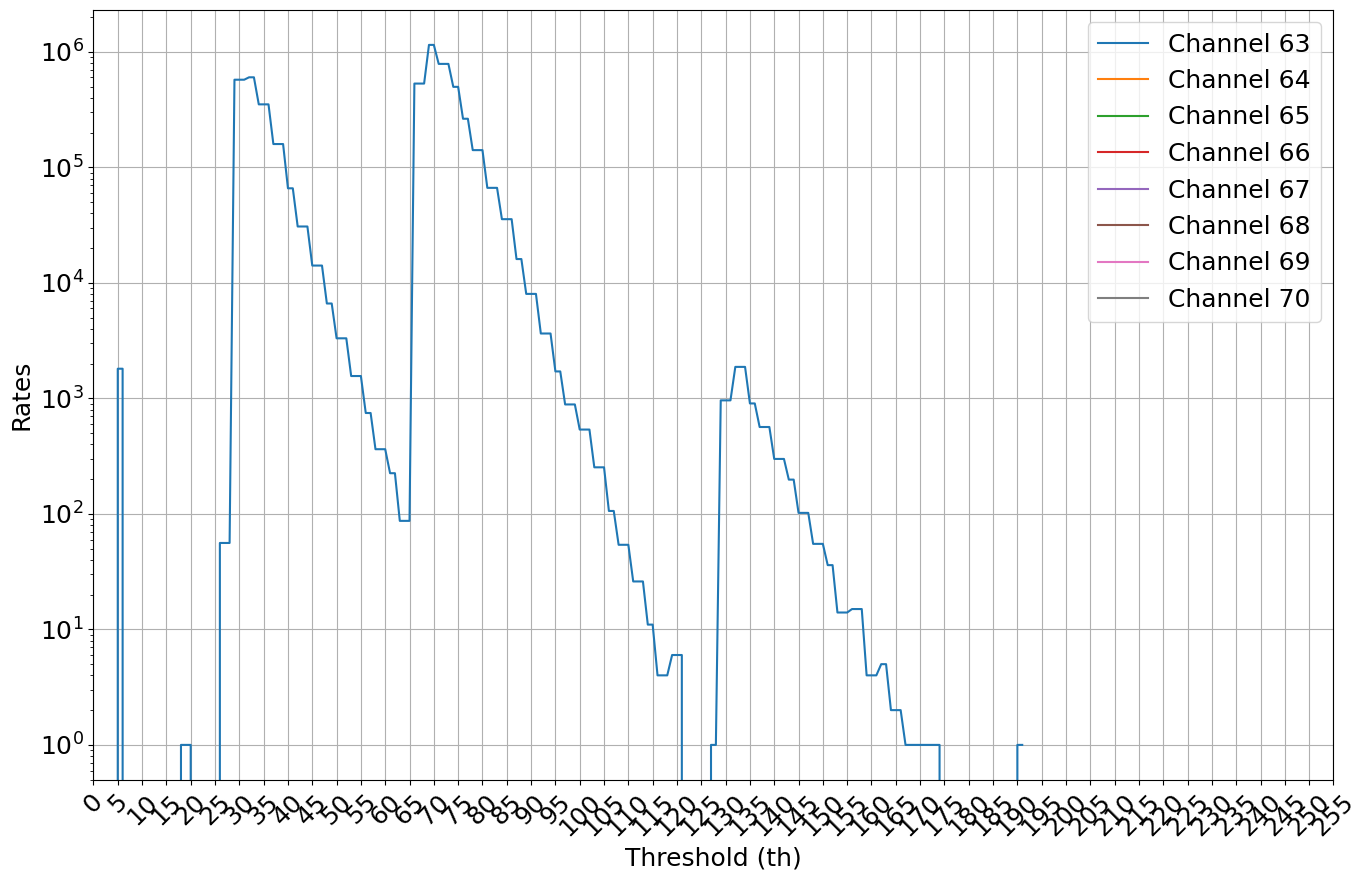

MIDAS DAC: -38


In [3]:
channelsA = [31,32,33,34,35,36,37,38]
channelsB = [39,40,41,42,43,44,45,46]
channelsC = [47,48,49,50,51,52,53,54]
channelsD = [55,56,57,58,59,60,61,62]
channelsD = [63,64,65,66,67,68,69,70]
referenz = 101
#with open('/home/mu3e/code_temp/Files/t/2026-05-18_13-23_tscan.json', 'r') as f:
with open('/home/nemu/musip/scripts/MutrigScripts/data/tThreshold_scan.json', 'r') as f:
    data = json.load(f)
    plot_threshold_scan(data, channelsD, referenz)
#with open('/home/mu3e/git-repos/online_testing/online/userfiles/sequencer/tiles/ThresholdScans/etheshold_scan15122025-HV56.0-module7-flippedETH.json', 'r') as f:
   # data = json.load(f)
    #plot_threshold_scan(data, channels)
print('MIDAS DAC:', 63 - referenz)


>>> Generiere Plot für Kanal 0...


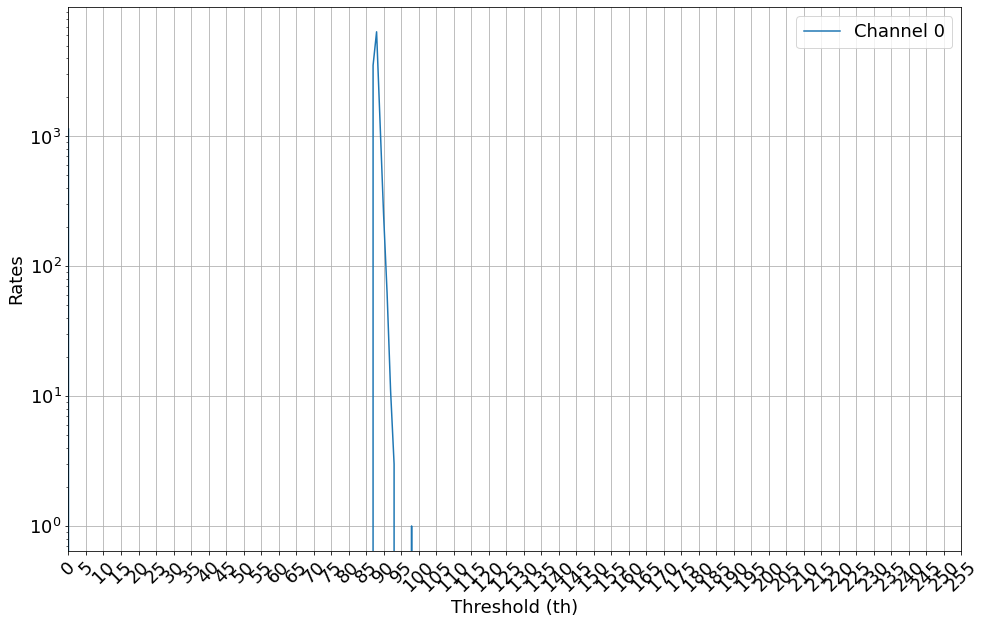


>>> Generiere Plot für Kanal 1...


/home/mu3e/.local/lib/python3.6/site-packages/ipykernel_launcher.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.


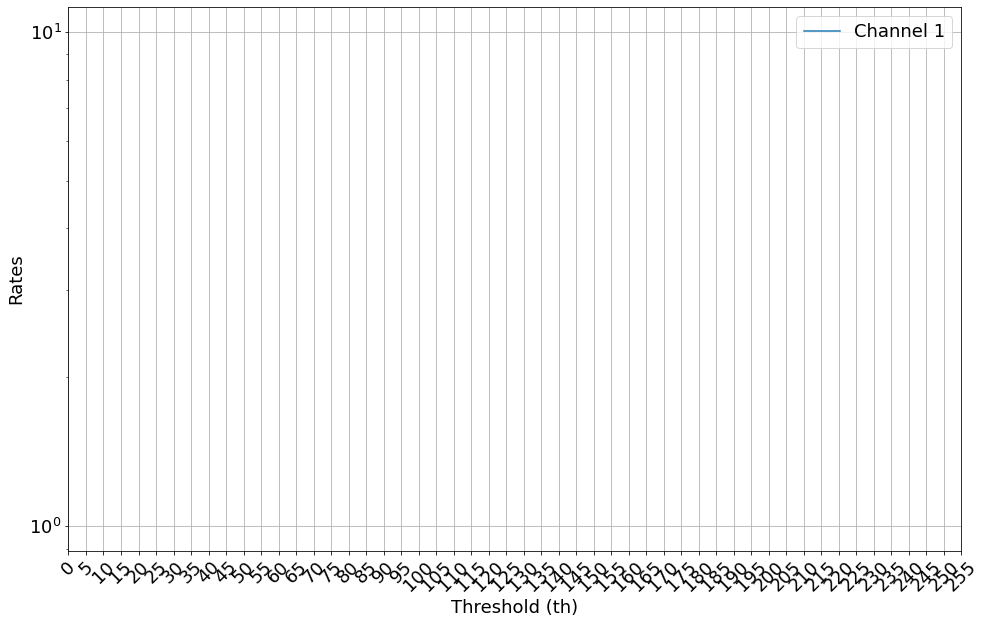


>>> Generiere Plot für Kanal 2...


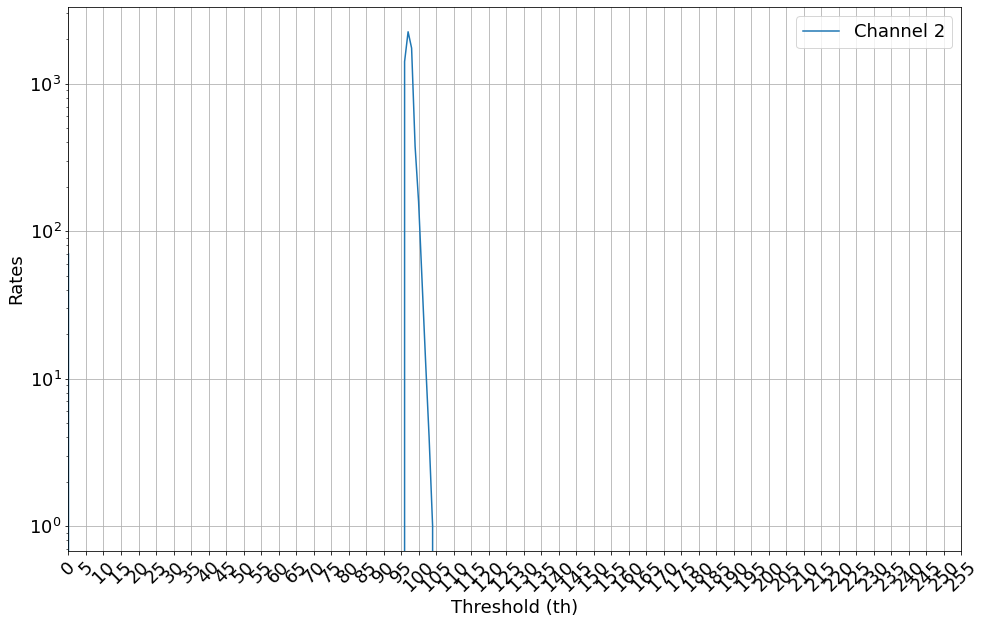


>>> Generiere Plot für Kanal 3...


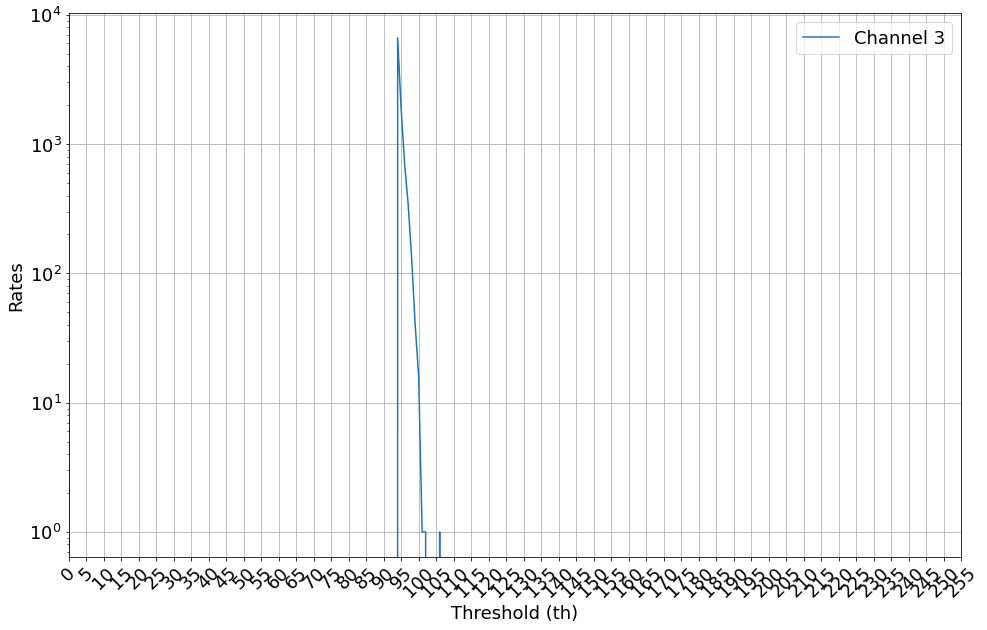


>>> Generiere Plot für Kanal 4...


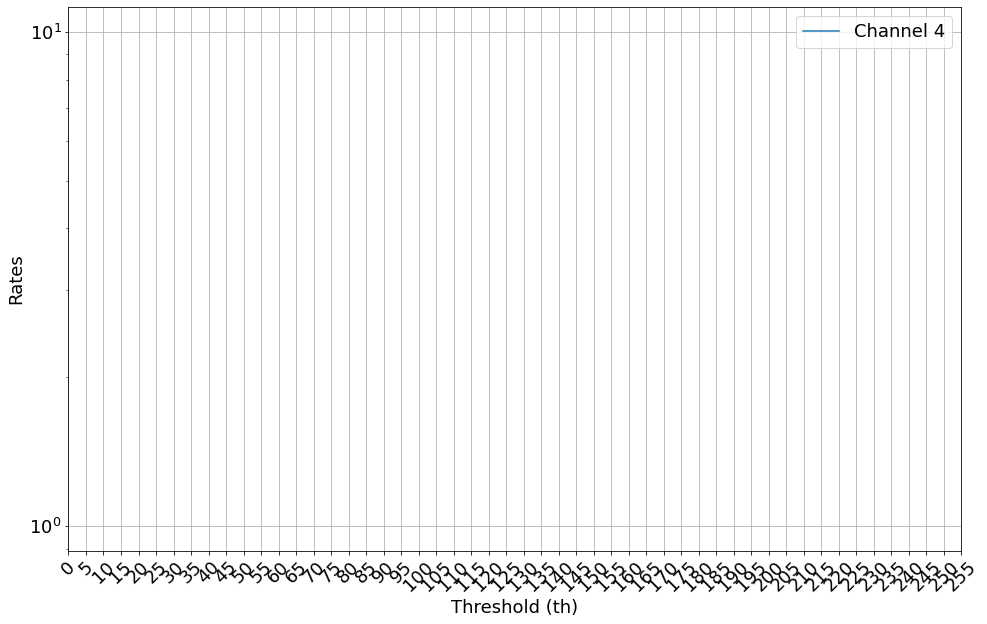


>>> Generiere Plot für Kanal 5...


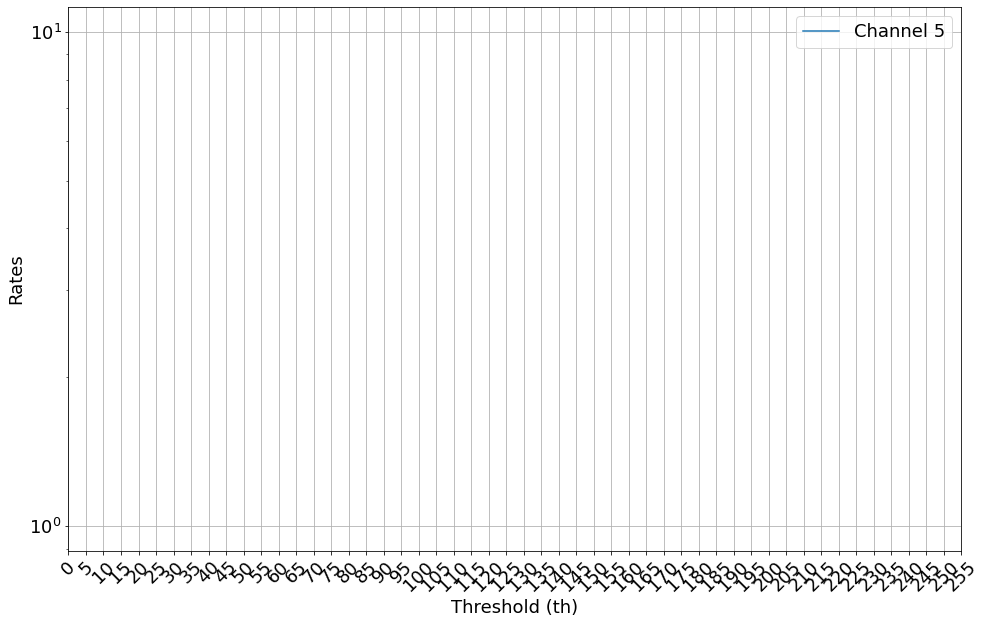


>>> Generiere Plot für Kanal 6...


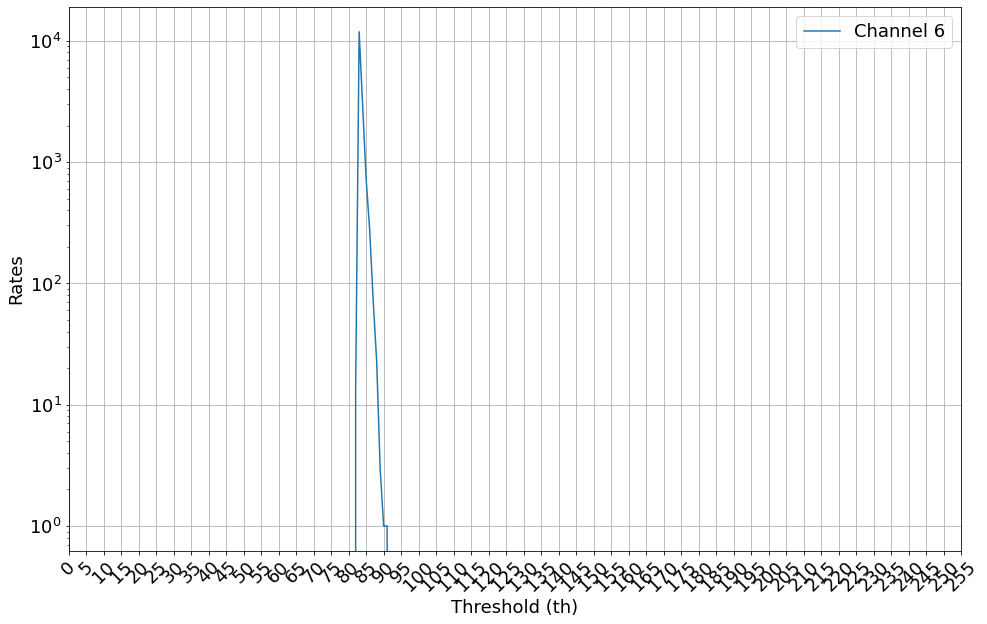


>>> Generiere Plot für Kanal 7...


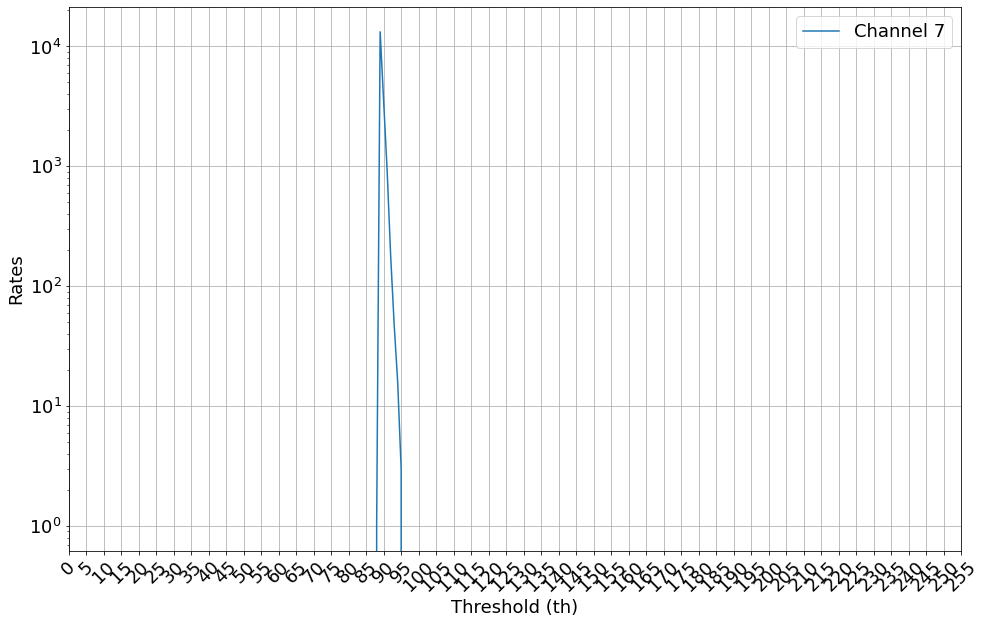


>>> Generiere Plot für Kanal 8...


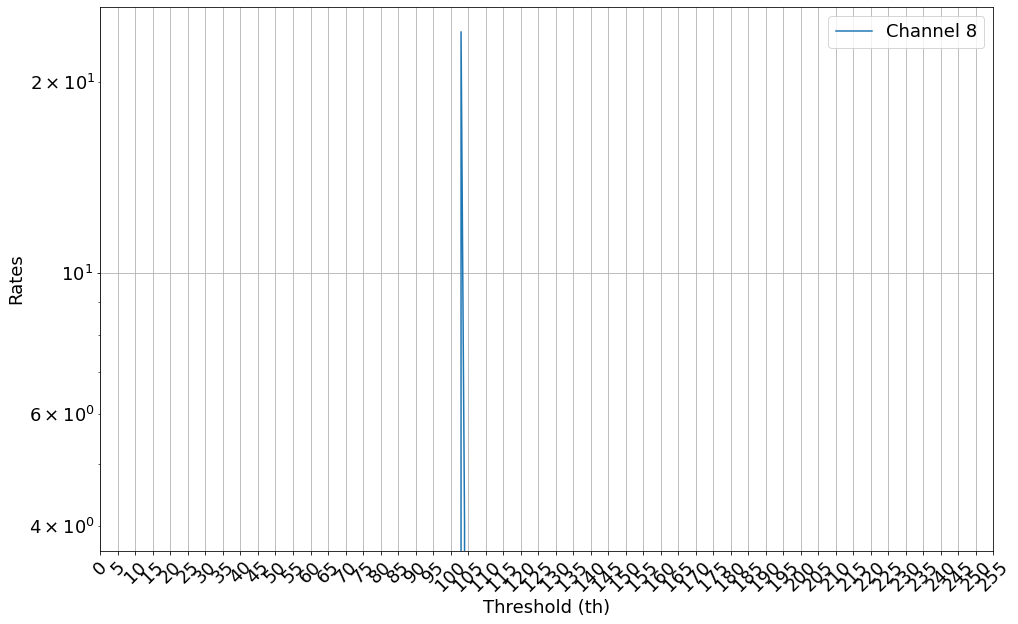


>>> Generiere Plot für Kanal 9...


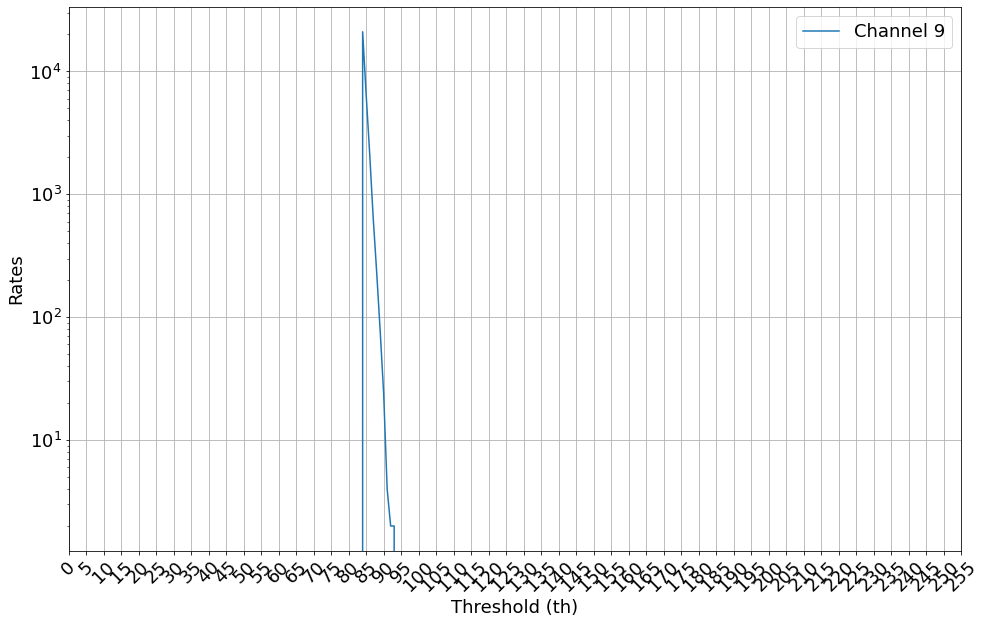


>>> Generiere Plot für Kanal 10...


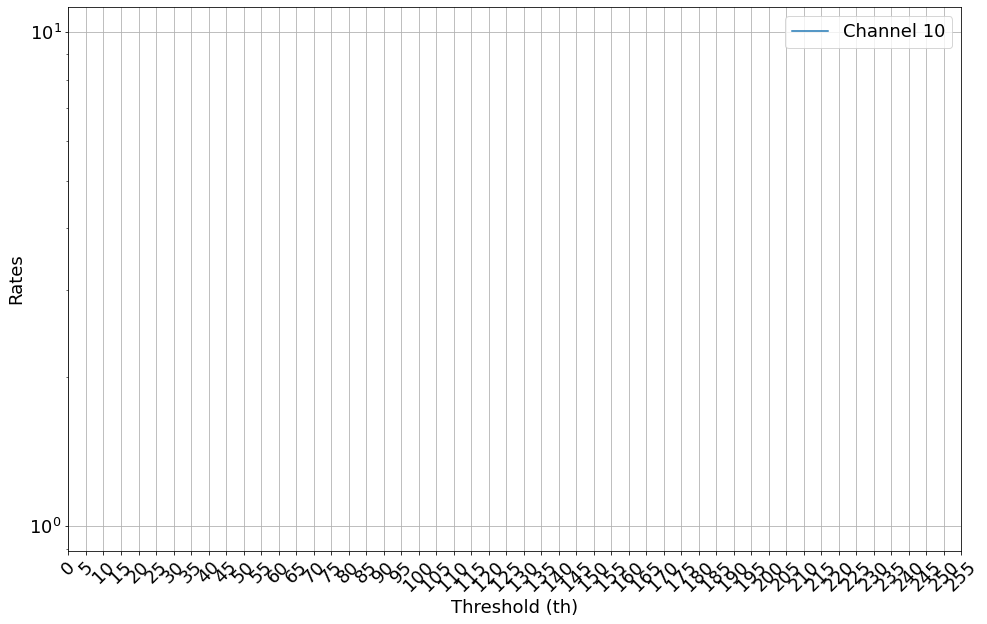


>>> Generiere Plot für Kanal 11...


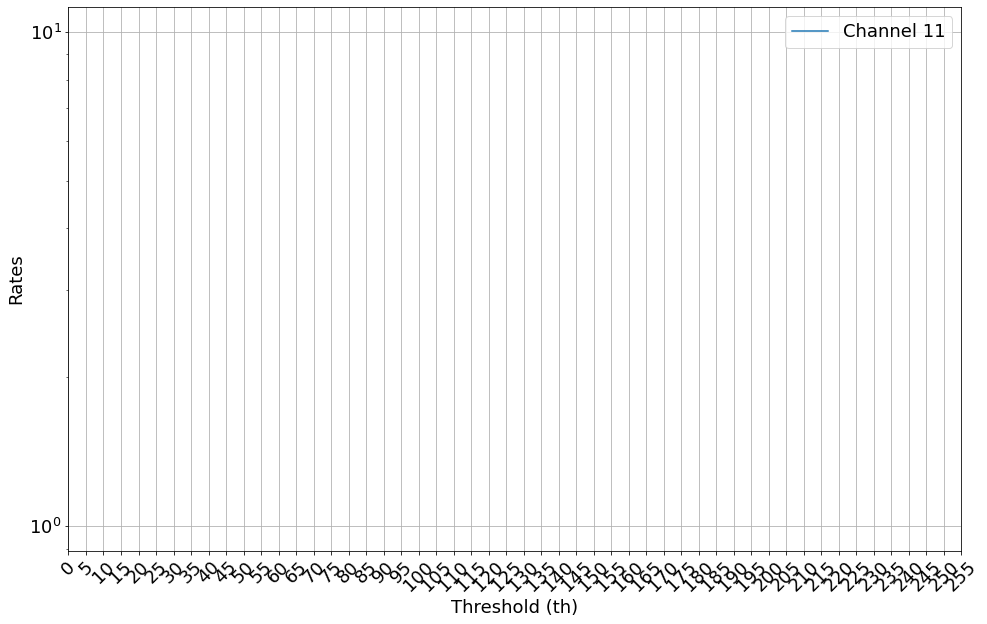


>>> Generiere Plot für Kanal 12...


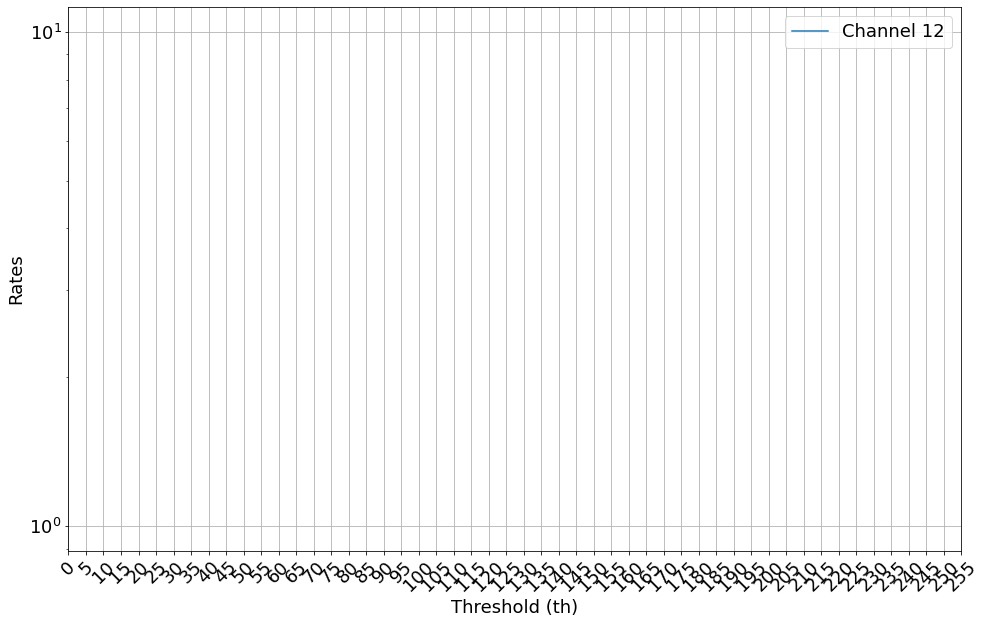


>>> Generiere Plot für Kanal 13...


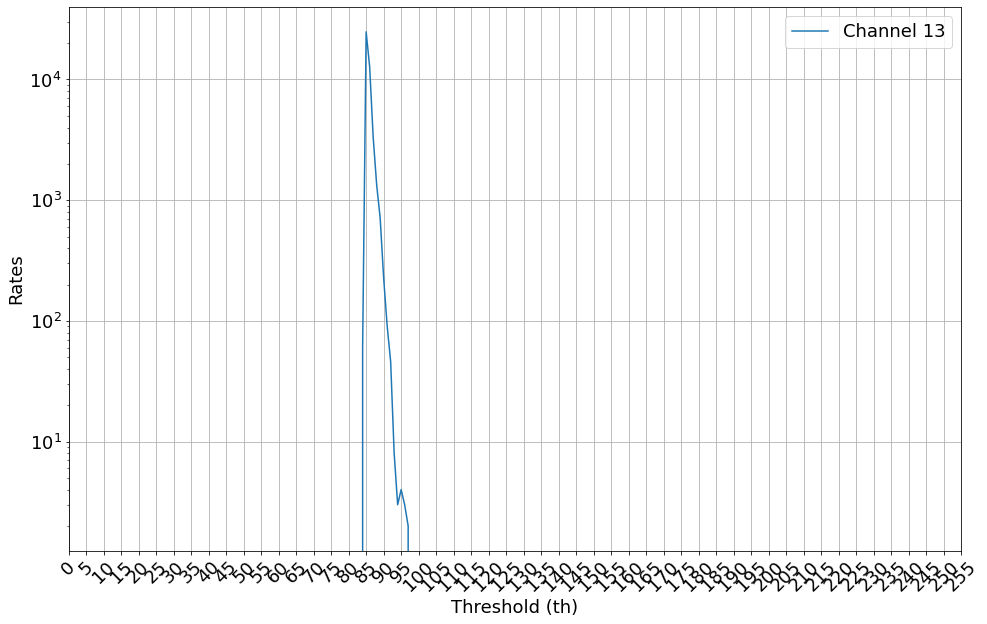


>>> Generiere Plot für Kanal 14...


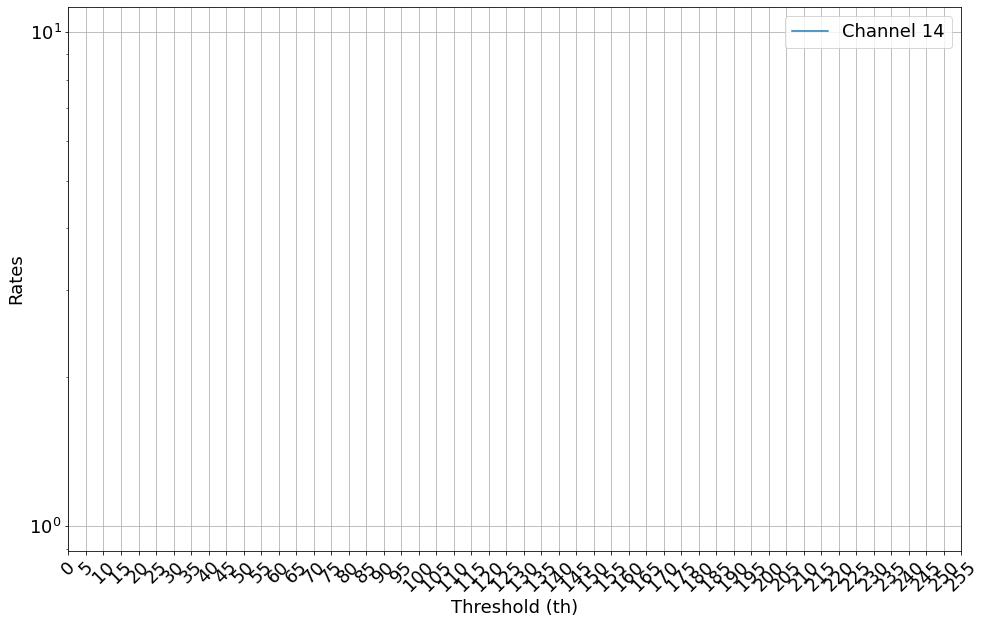


>>> Generiere Plot für Kanal 15...


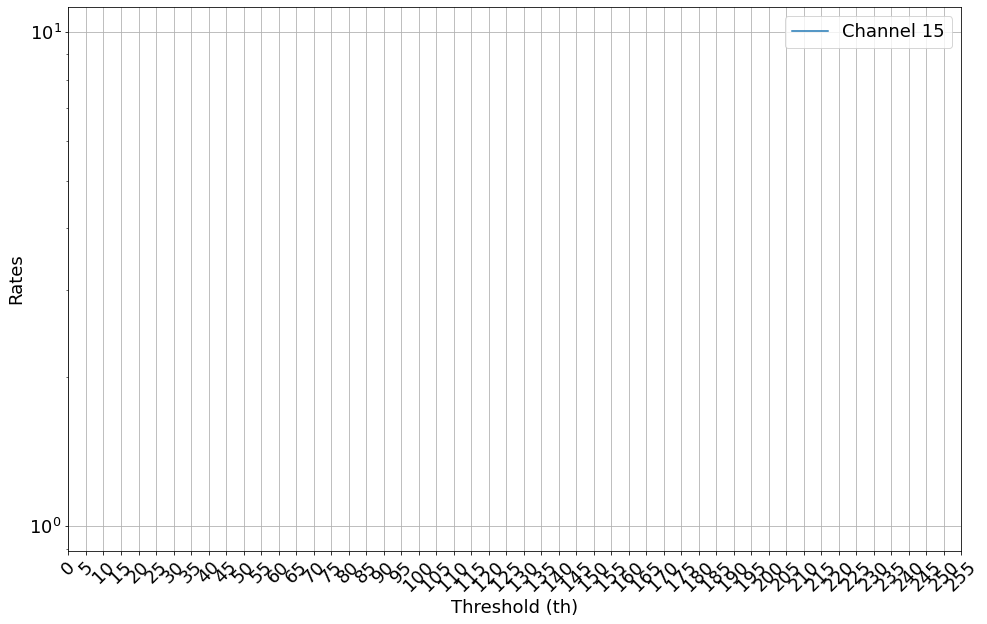


MIDAS DAC für Referenz: -38


In [7]:
import json
import matplotlib.pyplot as plt  # Falls du die Plots anzeigen/speichern willst
# Stelle sicher, dass die Funktion plot_threshold_scan importiert ist
# z.B. von deinem Analyse-Modul:
# from rate_calibration import plot_threshold_scan 

# Deine Kanäle definieren
channels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
referenz = 101

# JSON-Datei laden
with open('/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/AutoThreshhold/code_temp/Files/e/2026-05-18_13-23_escan.json', 'r') as f:
    data = json.load(f)

# Schleife über jeden einzelnen Kanal für separate Plots
for ch in channels:
    print(f"\n>>> Generiere Plot für Kanal {ch}...")
    
    # Wir übergeben eine Liste, die NUR diesen einen Kanal enthält
    plot_threshold_scan(data, [ch], referenz)
    
    # HINWEIS: Falls die Funktion plt.show() intern aufruft, öffnet sich 
    # ein Plot nach dem anderen. 
    # Falls du die Plots automatisch als Bild speichern willst, 
    # müsste man die Plot-Funktion eventuell anpassen.

print('\nMIDAS DAC für Referenz:', 63 - referenz)

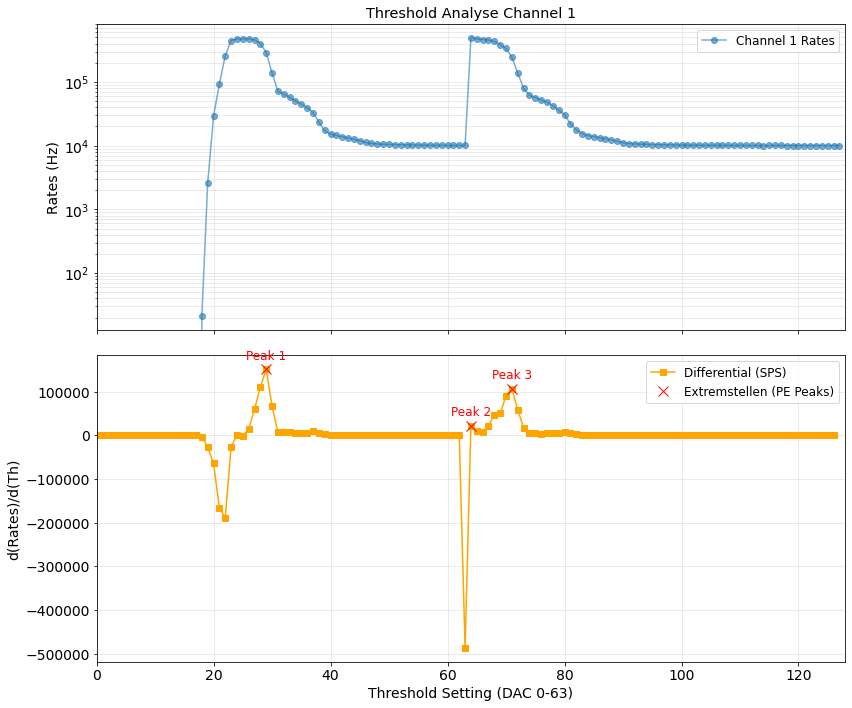

Gefundene Peaks bei TTh DAC-Werten: [29 64 71]
Vorschlag für T-Threshold (0.5 p.e. unter Peak 1): 72.5


In [15]:
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def plot_threshold_ana(data, ch):
    # Daten für den Kanal extrahieren
    th = np.array(data['th'][ch])
    rates = np.array(data['rates'][ch])
    
    # Da rates oft über viele Größenordnungen gehen, 
    # ist die Ableitung der Log-Raten manchmal stabiler.
    # Hier nutzen wir aber die klassische Differenz für das SPS:
    diff_rates = np.diff(rates) * -1  # *-1 damit die Peaks positiv sind
    th_diff = th[:-1] # X-Achse für die Ableitung (ein Element kürzer)

    # Peak-Suche in der Ableitung
    # 'distance' verhindert, dass Rauschen als mehrere Peaks erkannt wird
    # 'prominence' sorgt dafür, dass nur signifikante Hügel erkannt werden
    peaks, properties = find_peaks(diff_rates, distance=2, prominence=max(diff_rates)*0.05)

    # Plot erstellen (Zwei Subplots: Oben Raten, unten Ableitung)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    plt.rcParams.update({'font.size': 12})

    # Subplot 1: Originale Raten
    ax1.plot(th, rates, 'o-', label=f'Channel {ch} Rates', alpha=0.6)
    ax1.set_yscale('log')
    ax1.set_ylabel('Rates (Hz)')
    ax1.grid(True, which="both", alpha=0.3)
    ax1.legend()
    ax1.set_title(f"Threshold Analyse Channel {ch}")

    # Subplot 2: Ableitung (SPS)
    ax2.plot(th_diff, diff_rates, 's-', color='orange', label='Differential (SPS)')
    ax2.plot(th_diff[peaks], diff_rates[peaks], "x", color='red', markersize=10, label='Extremstellen (PE Peaks)')

    # Beschriftung der Peaks
    for i, peak_idx in enumerate(peaks):
        ax2.annotate(f"Peak {i+1}", (th_diff[peak_idx], diff_rates[peak_idx]), 
                     textcoords="offset points", xytext=(0,10), ha='center', color='red')

    ax2.set_ylabel('d(Rates)/d(Th)')
    ax2.set_xlabel('Threshold Setting (DAC 0-63)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.xlim(0, 128)
    plt.tight_layout()
    plt.show()

    # Ausgabe der gefundenen Werte für dein Tuning
    print(f"Gefundene Peaks bei TTh DAC-Werten: {th_diff[peaks]}")
    if len(peaks) > 0:
        print(f"Vorschlag für T-Threshold (0.5 p.e. unter Peak 1): {th_diff[peaks][-1] + 1.5}")

# Datei laden
file_path = '/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/check.json'
with open(file_path, 'r') as f:
    data = json.load(f)
    plot_threshold_ana(data, ch=1)

Fehler beim Laden von /home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/39_feb23.json: list indices must be integers or slices, not list
Fehler beim Laden von /home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/dark39_24feb.json: list indices must be integers or slices, not list


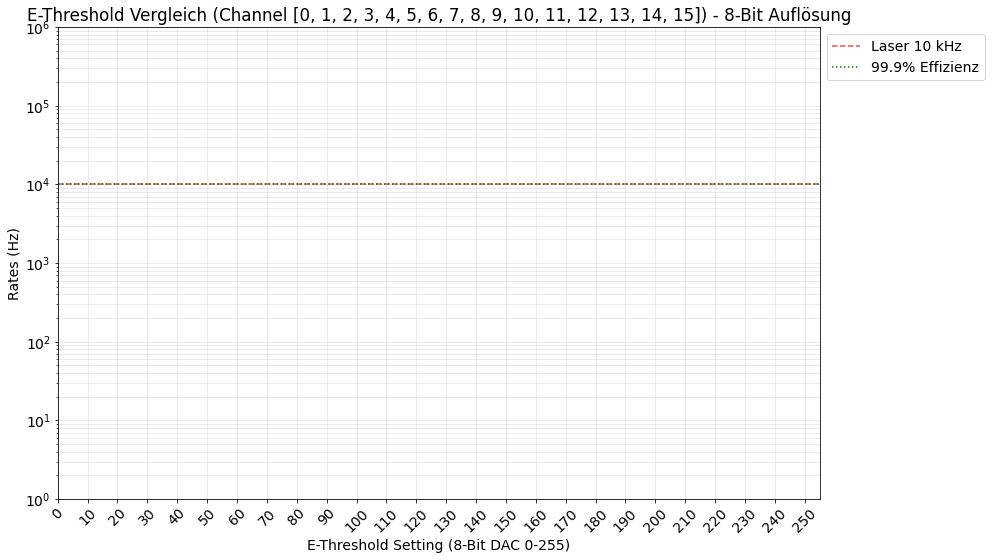

In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_ethreshold_scans(file_list, ch, laser_freq=10000):
    plt.figure(figsize=(14, 8))
    plt.rcParams.update({'font.size': 14})

    for file_path in file_list:
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            label_name = file_path.split('/')[-1].replace('.json', '')
            
            # Hier nutzen wir nun die volle Range bis 255
            th = data['th'][ch]
            rates = data['rates'][ch]
            
            plt.plot(th, rates, 'o-', markersize=3, label=f'T-Th: {label_name}')
        except Exception as e:
            print(f"Fehler beim Laden von {file_path}: {e}")

    # Referenzlinien
    plt.axhline(y=laser_freq, color='r', linestyle='--', alpha=0.7, label=f'Laser {laser_freq/1000:.0f} kHz')
    plt.axhline(y=laser_freq * 0.999, color='g', linestyle=':', label='99.9% Effizienz')

    plt.yscale('log')
    plt.xlabel('E-Threshold Setting (8-Bit DAC 0-255)')
    plt.ylabel('Rates (Hz)')
    plt.title(f'E-Threshold Vergleich (Channel {ch}) - 8-Bit Auflösung')
    
    # Gitter und Achsen anpassen
    plt.xticks(np.arange(0, 257, 10), rotation=45)
    plt.xlim(0, 255) 
    plt.ylim(1, 10**6) # Erweitert, falls das Rauschen stark ansteigt
    
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Dateipfade
base_path = '/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/'
files = [
    #base_path + '33_feb23.json',
    base_path + '39_feb23.json',
    base_path + 'dark39_24feb.json'
]

plot_combined_ethreshold_scans(files, ch=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15], laser_freq=10000)

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_ethreshold_scans(file_list, ch_list, laser_freq=10000):
    # Erstelle den Plot
    plt.figure(figsize=(15, 9))
    plt.rcParams.update({'font.size': 12})
    
    # Farbschema: tab20 bietet 20 unterscheidbare Farben
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    
    # Verschiedene Linienstile für die verschiedenen Dateien
    # Durchgezogen für die erste, gestrichelt für die zweite, gepunktet für die dritte
    line_styles = ['-', '--', ':', '-.']

    for f_idx, file_path in enumerate(file_list):
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            # Dateiname für die Legende extrahieren
            file_name = file_path.split('/')[-1].replace('.json', '')
            current_style = line_styles[f_idx % len(line_styles)]

            for ch in ch_list:
                # Sicherer Zugriff auf die Daten (egal ob Liste oder Dict mit String-Keys)
                try:
                    if isinstance(data['th'], list):
                        th = data['th'][ch]
                        rates = data['rates'][ch]
                    else:
                        th = data['th'][str(ch)]
                        rates = data['rates'][str(ch)]
                    
                    # Plotten der Kurve
                    # f_idx == 0 sorgt dafür, dass die Channel-Farben in der Legende 
                    # nicht doppelt erscheinen, wenn man es noch feiner filtern wollte.
                    # Hier plotten wir aber alles für volle Transparenz.
                    plt.plot(th, rates, 
                             linestyle=current_style, 
                             marker='o', 
                             markersize=2, 
                             color=colors[ch % 20], 
                             alpha=0.7,
                             label=f'Ch {ch:02d} ({file_name})')
                except (KeyError, IndexError):
                    print(f"Channel {ch} in Datei {file_name} nicht gefunden.")
                
        except Exception as e:
            print(f"Kritischer Fehler bei Datei {file_path}: {e}")

    # Referenzlinien
    plt.axhline(y=laser_freq, color='black', linestyle='-', linewidth=2, label='Laser Frequenz', zorder=10)
    plt.axhline(y=laser_freq * 0.99, color='red', linestyle=':', alpha=0.6, label='99% Effizienz-Grenze')

    # Achseneinstellungen
    plt.yscale('log')
    plt.xlabel('E-Threshold Setting (8-Bit DAC 0-255)')
    plt.ylabel('Rates (Hz)')
    plt.title(f'Multi-Channel Threshold Scan Vergleich\n(Dateien: {", ".join([f.split("/")[-1] for f in file_list])})')
    
    plt.xticks(np.arange(0, 257, 16))
    plt.xlim(0, 255)
    plt.ylim(1, 2 * 10**6) # Zeigt Rauschen bis 2 MHz
    
    plt.grid(True, which="both", ls="-", alpha=0.2)
    
    # Legende rechts außerhalb des Plots
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), ncol=2, fontsize='small', frameon=True)
    
    plt.tight_layout()
    plt.show()

# --- Konfiguration ---
base_path = '/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/'
files = [
    base_path + '39_feb23.json',
    base_path + 'dark39_24feb.json'
]

# Alle 16 Channels von 0 bis 15
channels_to_plot = list(range(16))

# Plot ausführen
plot_combined_ethreshold_scans(files, ch_list=channels_to_plot, laser_freq=10000)